Question 3

In [1]:
#Part (a)

import cv2 as cv
import numpy as np

# Number of matching points to click
N = 6
n = 0

p1 = np.empty((N, 2), dtype=np.float32)
p2 = np.empty((N, 2), dtype=np.float32)

# Mouse callback function
def draw_circle(event, x, y, flags, param):
    global n
    points = param[0]
    image = param[1]

    if event == cv.EVENT_LBUTTONDOWN:
        cv.circle(image, (x, y), 5, (255, 0, 0), -1)
        points[n] = (x, y)
        n += 1


# Load images
im1 = cv.imread("c1.jpg", cv.IMREAD_REDUCED_COLOR_4)
im2 = cv.imread("c2.jpg", cv.IMREAD_REDUCED_COLOR_4)

if im1 is None or im2 is None:
    print("Error: Images not found. Check the image path.")
    exit()

im1copy = im1.copy()
im2copy = im2.copy()

# Click 6 points on image 1
cv.namedWindow("Image 1")
param = [p1, im1copy]
cv.setMouseCallback("Image 1", draw_circle, param)

while True:
    cv.imshow("Image 1", im1copy)

    if n == N:
        break

    if cv.waitKey(20) & 0xFF == 27:
        break

cv.destroyWindow("Image 1")

# Click same 6 corresponding points on image 2
n = 0
cv.namedWindow("Image 2")
param = [p2, im2copy]
cv.setMouseCallback("Image 2", draw_circle, param)

while True:
    cv.imshow("Image 2", im2copy)

    if n == N:
        break

    if cv.waitKey(20) & 0xFF == 27:
        break

cv.destroyWindow("Image 2")

print("Points from image 1:")
print(p1)

print("Points from image 2:")
print(p2)

# Compute homography
H, mask = cv.findHomography(p1, p2, cv.RANSAC)

print("Homography Matrix:")
print(H)

# Warp image 1 to image 2 perspective
height, width = im2.shape[:2]
warped_im1 = cv.warpPerspective(im1, H, (width, height))

# Display results
cv.imshow("Original Image 1", im1)
cv.imshow("Original Image 2", im2)
cv.imshow("Warped Image 1 to Image 2 Perspective", warped_im1)

cv.waitKey(0)
cv.destroyAllWindows()


#Question 3 Part (b)

# Convert to grayscale
gray_warped = cv.cvtColor(warped_im1, cv.COLOR_BGR2GRAY)
gray_im2 = cv.cvtColor(im2, cv.COLOR_BGR2GRAY)

# Compute difference
diff = cv.absdiff(gray_im2, gray_warped)

# Display ONLY the difference image (as required)
cv.imshow("Difference Image", diff)

cv.waitKey(0)
cv.destroyAllWindows()


Points from image 1:
[[243.  57.]
 [502. 152.]
 [323. 635.]
 [ 74. 537.]
 [291. 358.]
 [241. 473.]]
Points from image 2:
[[322.  26.]
 [546. 183.]
 [242. 603.]
 [ 32. 446.]
 [288. 322.]
 [212. 425.]]
Homography Matrix:
[[ 1.17721505e+00 -2.84721686e-01  1.01403341e+02]
 [ 5.18499460e-01  1.26575068e+00 -2.21599505e+02]
 [ 4.64257220e-04  1.46784674e-04  1.00000000e+00]]


Number of keypoints in Image 1: 1000
Number of keypoints in Image 2: 1000


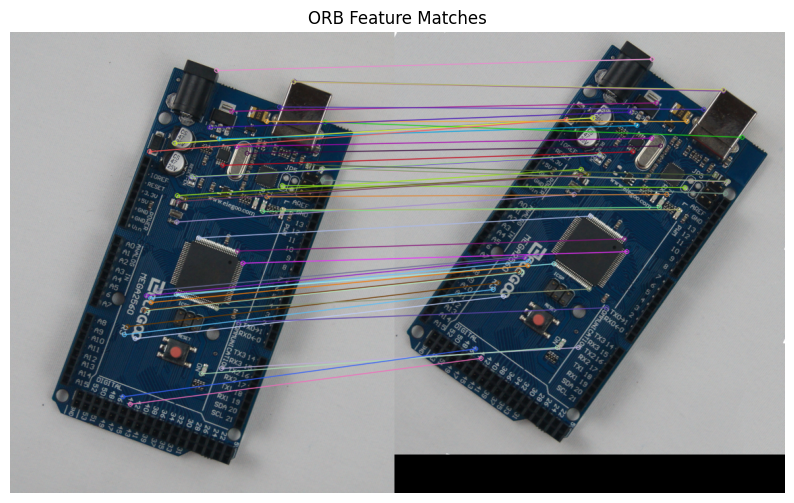

In [1]:
#Part (c)

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load images
im1 = cv.imread("c1.jpg", cv.IMREAD_REDUCED_COLOR_4)
im2 = cv.imread("c2.jpg", cv.IMREAD_REDUCED_COLOR_4)

if im1 is None or im2 is None:
    print("Error: Images not found. Check the image paths.")
    exit()

# Convert to grayscale
gray1 = cv.cvtColor(im1, cv.COLOR_BGR2GRAY)
gray2 = cv.cvtColor(im2, cv.COLOR_BGR2GRAY)

# Create ORB detector
orb = cv.ORB_create(nfeatures=1000)

# Detect keypoints and compute descriptors
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

print("Number of keypoints in Image 1:", len(kp1))
print("Number of keypoints in Image 2:", len(kp2))

# Match descriptors using Brute Force Matcher
bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

# Sort matches based on distance
matches = sorted(matches, key=lambda x: x.distance)

# Select best matches
best_matches = matches[:50]

# Draw matches
matched_image = cv.drawMatches(
    im1, kp1,
    im2, kp2,
    best_matches,
    None,
    flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Convert BGR → RGB for correct display
matched_rgb = cv.cvtColor(matched_image, cv.COLOR_BGR2RGB)

# Display inside VS Code output (not separate window)
plt.figure(figsize=(10, 6))
plt.imshow(matched_rgb)
plt.title("ORB Feature Matches")
plt.axis("off")
plt.show()

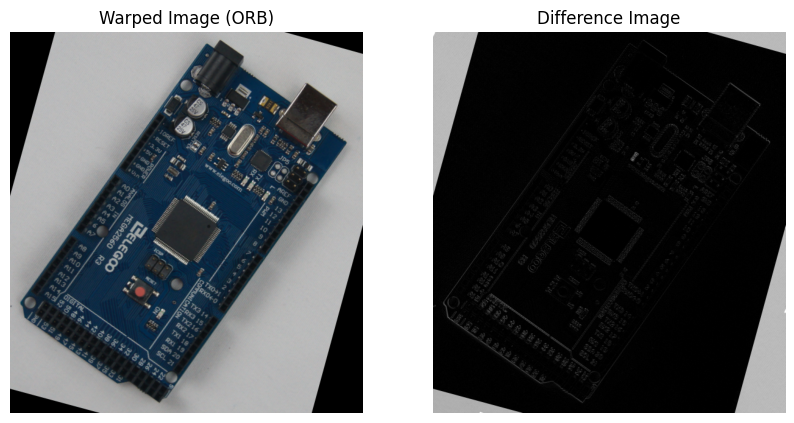

In [2]:
#Part (d)

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load images
im1 = cv.imread("c1.jpg", cv.IMREAD_REDUCED_COLOR_4)
im2 = cv.imread("c2.jpg", cv.IMREAD_REDUCED_COLOR_4)

# Convert to grayscale
gray1 = cv.cvtColor(im1, cv.COLOR_BGR2GRAY)
gray2 = cv.cvtColor(im2, cv.COLOR_BGR2GRAY)

# ORB
orb = cv.ORB_create(nfeatures=1000)
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

# Matching
bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

good_matches = matches[:100]

# Extract points
pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches])

# Homography
H, _ = cv.findHomography(pts1, pts2, cv.RANSAC)

# Warp
h, w = im2.shape[:2]
warped = cv.warpPerspective(im1, H, (w, h))

# Difference
diff = cv.absdiff(
    cv.cvtColor(im2, cv.COLOR_BGR2GRAY),
    cv.cvtColor(warped, cv.COLOR_BGR2GRAY)
)

# Convert BGR → RGB for matplotlib
warped_rgb = cv.cvtColor(warped, cv.COLOR_BGR2RGB)

# Display inline
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Warped Image (ORB)")
plt.imshow(warped_rgb)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Difference Image")
plt.imshow(diff, cmap='gray')
plt.axis('off')

plt.show()